In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data = pd.read_csv('hand cleaned data to share.csv')
joints = ['DIP2', 'DIP3', 'DIP4', 'DIP5', 
          'PIP2', 'PIP3', 'PIP4', 'PIP5',
          'MCP2', 'MCP3', 'MCP4', 'MCP5']
tps = ['v00', 'v06']
hands = {0: 'left', 1: 'right'}


In [21]:
print(data.shape)
nnz = data[data!=0]
nnz.info()

(3590, 99)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3590 entries, 0 to 3589
Data columns (total 99 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   v00DIP2_KL   1679 non-null   float64
 1   v00DIP3_KL   1334 non-null   float64
 2   v00DIP4_KL   1069 non-null   float64
 3   v00DIP5_KL   1677 non-null   float64
 4   v00PIP2_KL   854 non-null    float64
 5   v00PIP3_KL   1220 non-null   float64
 6   v00PIP4_KL   1402 non-null   float64
 7   v00PIP5_KL   1006 non-null   float64
 8   v00MCP2_KL   445 non-null    float64
 9   v00MCP3_KL   447 non-null    float64
 10  v00MCP4_KL   67 non-null     float64
 11  v00MCP5_KL   42 non-null     float64
 12  Hand         265 non-null    float64
 13  v06DIP2_KL   1773 non-null   float64
 14  v06DIP3_KL   1421 non-null   float64
 15  v06DIP4_KL   1113 non-null   float64
 16  v06DIP5_KL   1736 non-null   float64
 17  v06PIP2_KL   899 non-null    float64
 18  v06PIP3_KL   1250 non-null   float64


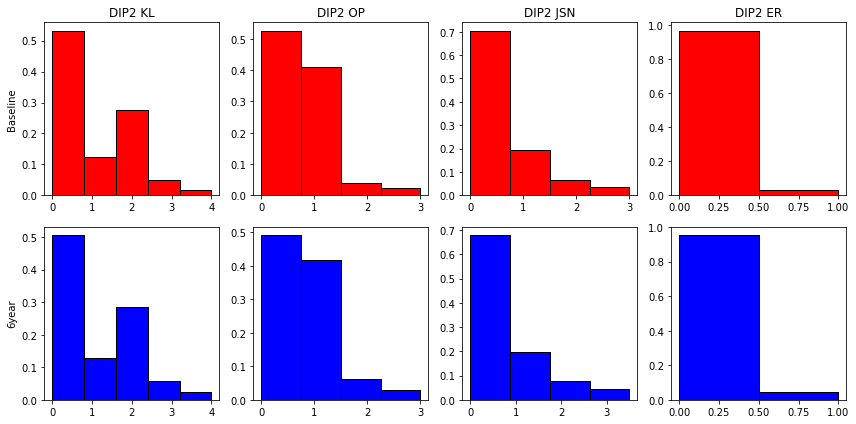

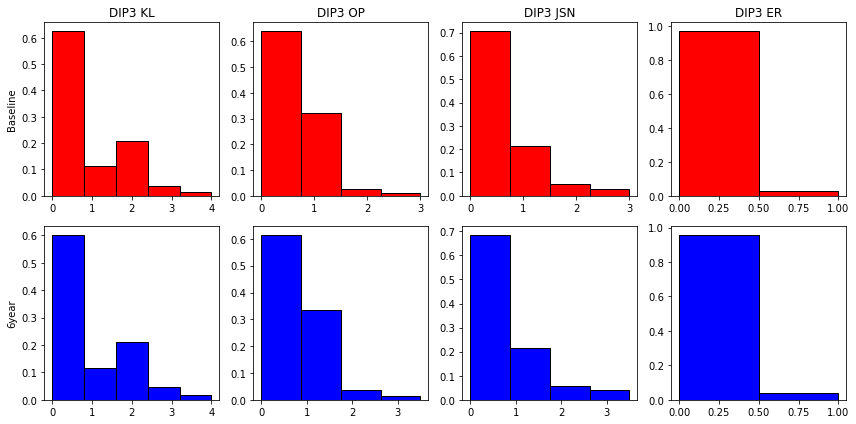

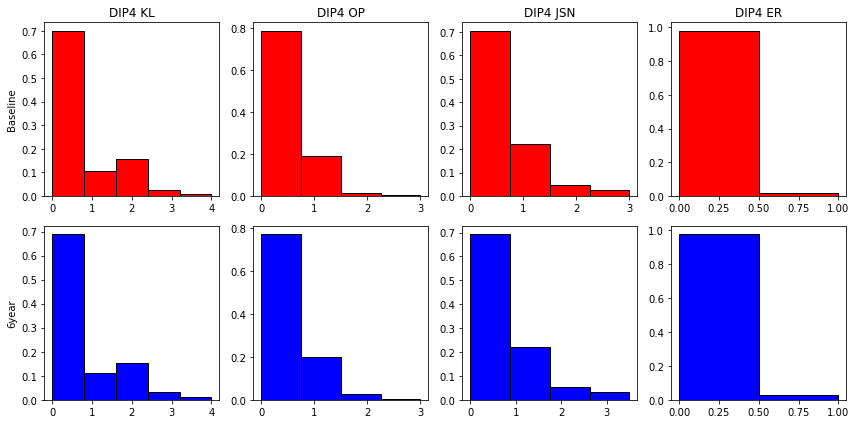

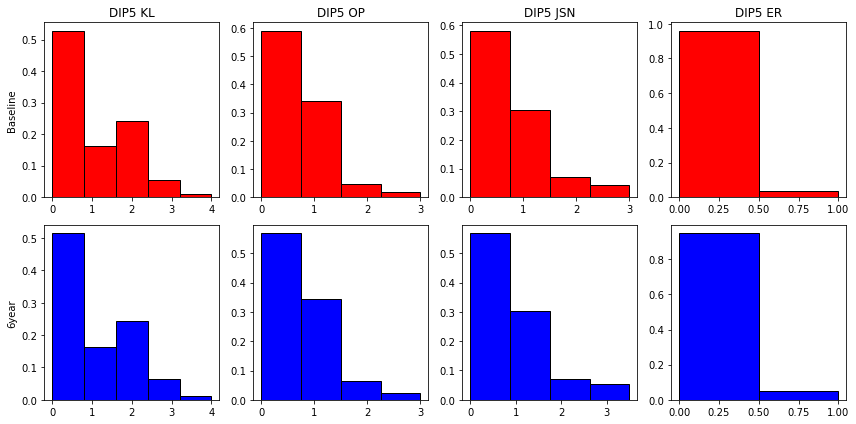

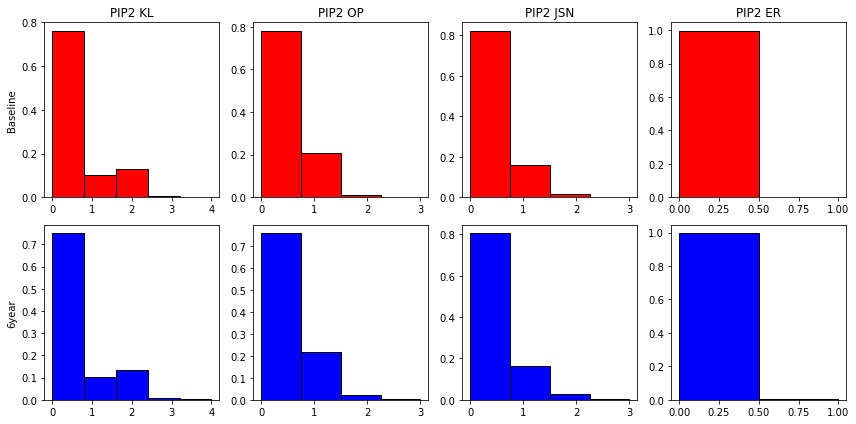

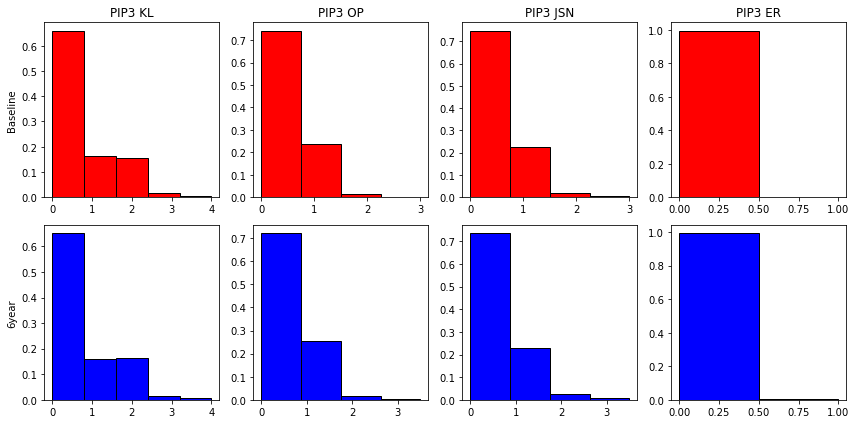

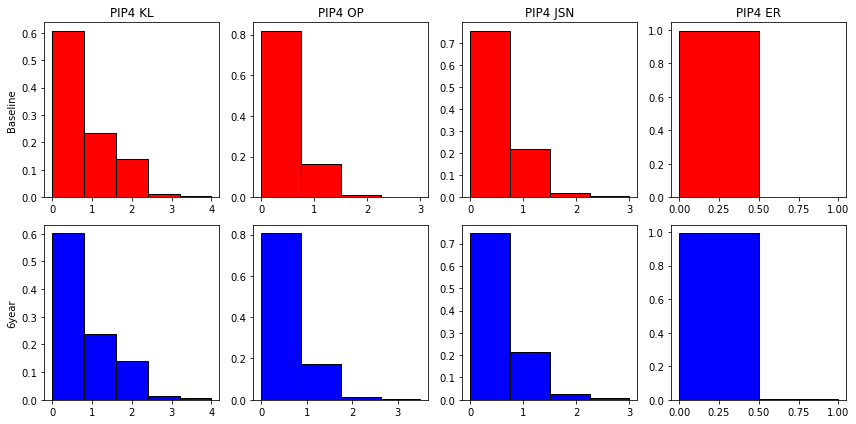

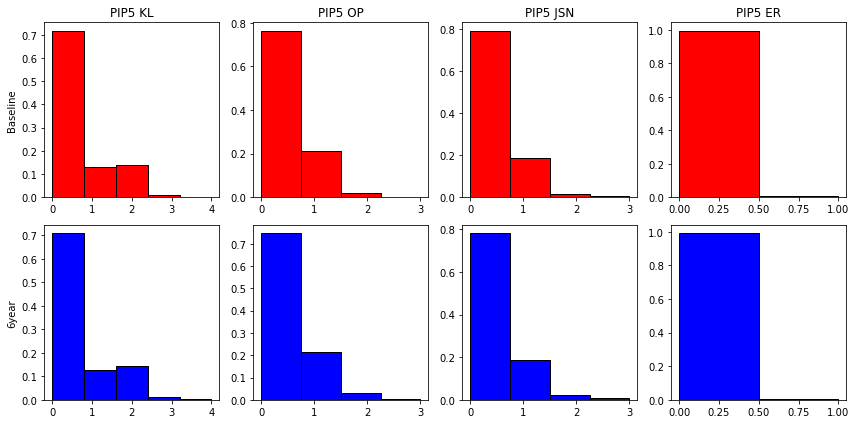

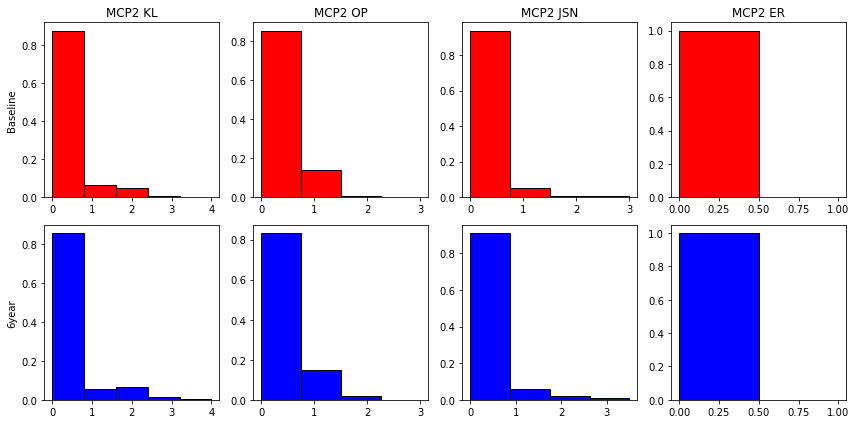

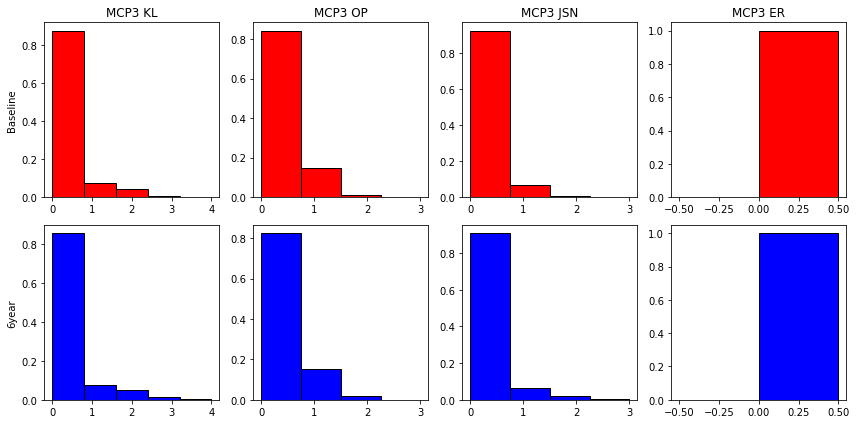

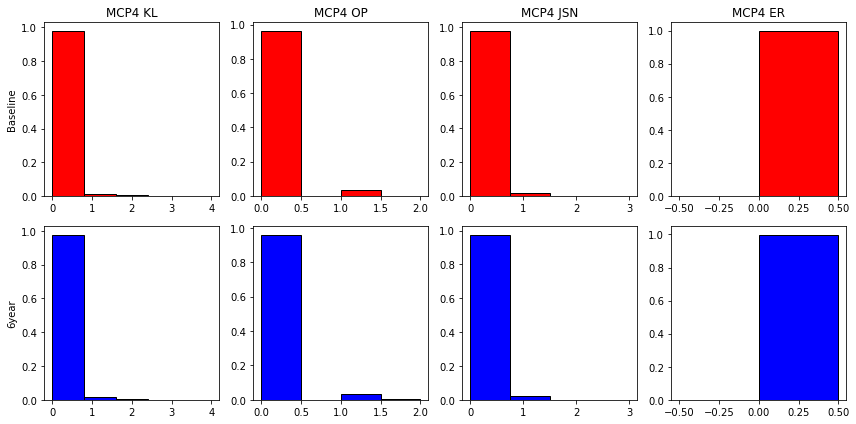

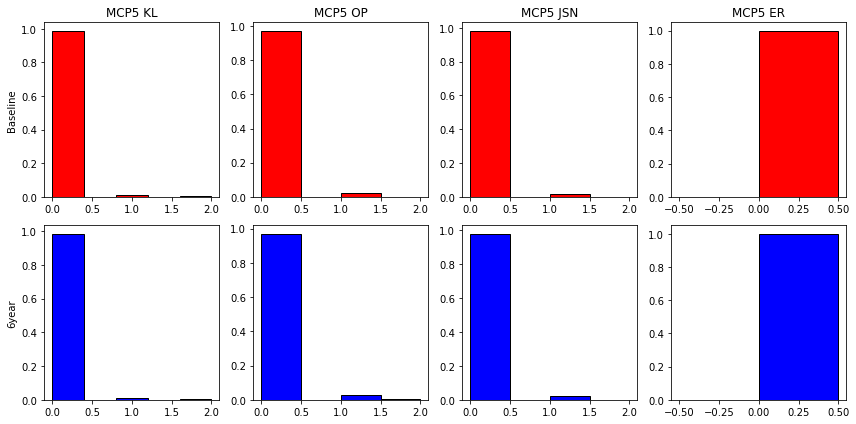

In [3]:
scores = pd.DataFrame()
scores['Joint'] = ''
lims = {'KL':[0,4], 'JSN':[0,3], 'OP':[0,3], 'ER':[0,1]}
for joint in joints:
    tmp = data[[c for c in data.columns if joint in c] + ['v00hand','v06hand']].copy()
    # break up by timepoint
    v00 = tmp[[c for c in tmp.columns if c.startswith('v00')]]
    v00 = v00.drop(columns='v00hand')
    v06 = tmp[[c for c in tmp.columns if c.startswith('v06')]]
    v06 = v06.drop(columns='v06hand')
    # make histograms
    fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12,6))
    for i,col in enumerate(v00.columns):
        metric = col.split('_')[1]
        ax[0,i].hist(v00[col], bins=lims[metric][1]+1, 
                     weights=np.ones(v00.shape[0])/v00.shape[0], color='red', edgecolor='black')
        ax[0,i].set_title(f'{joint} {metric}')
        ax[0,0].set_ylabel('Baseline')
        ax[1,i].hist(v06[col.replace('v00','v06')], bins=lims[metric][1]+1, 
                     weights=np.ones(v06.shape[0])/v06.shape[0], color='blue', edgecolor='black')
        ax[1,0].set_ylabel('6year')
        plt.tight_layout()
    fig.savefig(f'./stats_figures/{joint}_hist.svg')

    # collect aggregate data
    meandat = pd.concat([pd.DataFrame(v00.mean()), pd.DataFrame(v06.mean())], axis=0).T
    stddat = pd.concat([pd.DataFrame(v00.std()), pd.DataFrame(v06.std())], axis=0).T
    tmp = pd.DataFrame()
    for metric in ['ER', 'JSN', 'KL', 'OP']:
        for tp in ['v00', 'v06']:
            meanval = str(np.round(meandat[f'{tp}{joint}_{metric}'].values[0],2))
            stdval = str(np.round(stddat[f'{tp}{joint}_{metric}'].values[0],2))
            comboval = meanval + ' ± ' + stdval
            tmp[f'{metric} {tp}'] = [comboval]
            tmp['Joint'] = joint
            scores = pd.concat([scores, tmp], ignore_index=True)
            
    scores = scores.dropna(axis=0).reset_index(drop=True)
scores.to_csv('./stats_figures/aggDataStatistics.csv', index=False)

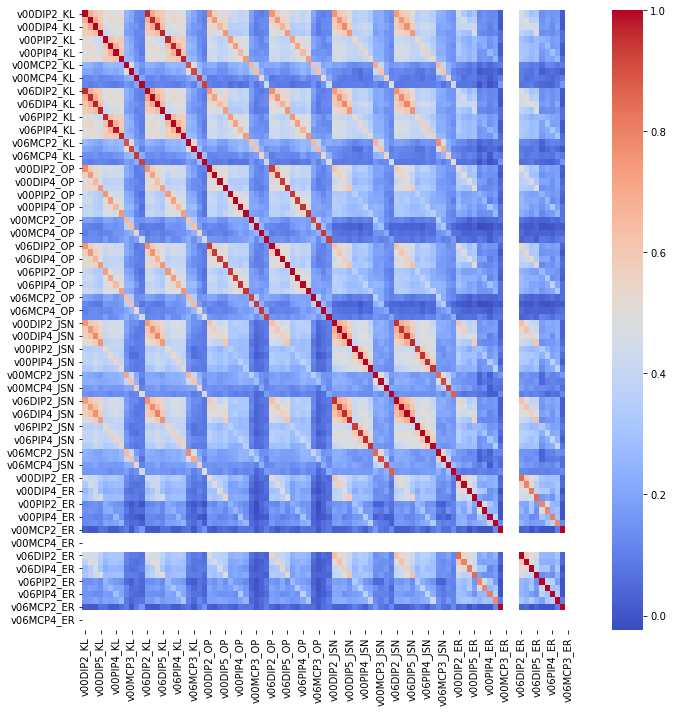

In [9]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(data.drop(columns=['v00hand','v06hand','Hand']).corr(), ax=ax, cmap='coolwarm')
plt.tight_layout()
plt.show()